# 📊 Notebook-01: ML-Modellvergleich
**KI Advanced · IA1017000 · HfPolBW**

---

**Session:** S 1.2 – KI-Paradigmen & Anwendungen
**Ziel:** Entscheidungsbaum vs. MLP auf echten und realistischen Datensätzen vergleichen.
**Dauer:** ~30 Minuten

---

| Teil | Inhalt | Schwerpunkt |
|------|--------|-------------|
| **1** | Iris-Datensatz laden & erkunden | Features, Labels, Visualisierung |
| **2** | Entscheidungsbaum trainieren | Supervised Learning, Baumvisualisierung |
| **3** | MLP (neuronales Netz) trainieren | Vergleich mit Baum, Loss-Kurve |
| **4** | Konfusionsmatrix & Metriken | Precision, Recall, F1-Score |
| **5** | 🚔 NSL-KDD: Echte Netzwerkangriffe | Polizei-Kontext: Netzwerk-Forensik |

---

> ### 📌 Wie benutze ich dieses Notebook?
>
> Ein Notebook besteht aus **Zellen** — entweder **Text-Zellen** (wie diese hier) oder **Code-Zellen** (grauer Hintergrund mit `[ ]` links).
>
> **Alles auf einmal ausführen:** Menü → *Runtime → Run all*
>
> **Einzelne Zelle ausführen:** Zelle anklicken → `Shift + Enter`
>
> Sie müssen **keinen Code schreiben** — lesen, verstehen, beobachten.
> Jede Code-Zelle ist vollständig kommentiert und erklärt.


---
## ⚙️ Setup – Bibliotheken laden

Bevor wir starten, müssen wir die **Werkzeugkästen** laden, die Python für Machine Learning
und Visualisierung benötigt. Das ist vergleichbar mit dem Öffnen von Fachanwendungen:
Man startet erst die Software, bevor man arbeiten kann.

**Was laden wir?**
- `numpy / pandas` → Daten einlesen und verarbeiten (wie Excel, nur für Code)
- `matplotlib` → Diagramme und Grafiken erzeugen
- `sklearn` → Der Standard-Werkzeugkasten für Machine Learning in Python


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SETUP: Alle benötigten Bibliotheken (Werkzeugkästen) werden hier geladen.
# Dieser Schritt muss immer als erstes ausgeführt werden.
# ─────────────────────────────────────────────────────────────────────────────

# numpy: Mathematische Operationen, Zufallszahlen, Arrays (Zahlenlisten)
import numpy as np

# pandas: Tabellen (sog. DataFrames) – wie Excel-Tabellen im Code
import pandas as pd

# matplotlib: Grafiken und Diagramme erstellen
import matplotlib.pyplot as plt

# Warnungen unterdrücken (technische Hinweise, die uns hier nicht interessieren)
import warnings; warnings.filterwarnings('ignore')

# ── Aus sklearn laden wir einzelne Komponenten: ──────────────────────────────

# Den Iris-Datensatz (direkt in sklearn eingebaut)
from sklearn.datasets import load_iris

# Funktion zum Aufteilen in Training- und Testdaten
from sklearn.model_selection import train_test_split

# Der Entscheidungsbaum-Algorithmus
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# Das neuronale Netz (MLP = Multi-Layer Perceptron)
from sklearn.neural_network import MLPClassifier

# Skalierung: Bringt alle Features auf dieselbe Größenordnung
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Metriken: Werkzeuge zur Bewertung eines Modells
from sklearn.metrics import (
    accuracy_score,        # Trefferquote
    classification_report, # Detaillierter Bericht mit Precision/Recall/F1
    confusion_matrix,      # Verwechslungsmatrix
    ConfusionMatrixDisplay, # Visualisierung der Verwechslungsmatrix
    f1_score,
    precision_score,
    recall_score
)

# ── Farbpalette für einheitliche Visualisierungen ────────────────────────────
# Wir definieren Farben als Dictionary (Nachschlageliste), damit alle
# Diagramme im gleichen Corporate-Look erscheinen.
C = {
    'navy':  '#001E46',   # Dunkler Hintergrund
    'blue1': '#0D3761',   # Etwas helleres Blau
    'ice':   '#4FC3F7',   # Hellblau (Überschriften)
    'orange':'#ED7D31',   # Orange (Hervorhebungen)
    'green': '#52B788',   # Grün (positive Werte)
    'teal':  '#00B4D8',   # Türkis
    'lgray': '#B0C4DE',   # Hellgrau (Achsenbeschriftungen)
    'white': '#FFFFFF',   # Weiß
    'purple':'#9B59B6',   # Lila
    'red':   '#E74C3C'    # Rot (Warnungen / Angriffe)
}

# Matplotlib-Standardeinstellungen für dunkles Design setzen
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': C['navy'],
    'axes.facecolor':   C['blue1'],
    'axes.edgecolor':   C['lgray'],
    'axes.labelcolor':  C['lgray'],
    'xtick.color':      C['lgray'],
    'ytick.color':      C['lgray'],
    'text.color':       C['white'],
    'grid.color':       '#1A4E8A',
    'grid.alpha':       0.4,
    'font.size':        11
})

# Kontrollausgabe: Zeigt an, dass alles geladen wurde
print('✅  Setup OK – alle Bibliotheken geladen')


✅  Setup OK – alle Bibliotheken geladen


---
## Teil 1 – Der Iris-Datensatz: Daten verstehen bevor man modelliert

### 🌸 Was ist der Iris-Datensatz?

Der **Iris-Datensatz** ist der bekannteste Lern-Datensatz im Machine Learning.
Er enthält Messungen von **150 Schwertlilien** (Blumen) dreier Arten:

| Klasse | Bedeutung |
|--------|-----------|
| `setosa` | Borsten-Schwertlilie |
| `versicolor` | Verschiedenfarbige Schwertlilie |
| `virginica` | Virginische Schwertlilie |

Jede Blume ist durch **4 Messungen (Features)** beschrieben:
- **sepal length** – Länge des Kelchblatts (cm)
- **sepal width** – Breite des Kelchblatts (cm)
- **petal length** – Länge des Blütenblatts (cm)
- **petal width** – Breite des Blütenblatts (cm)

### 🔑 Warum lernen wir damit?

Der Iris-Datensatz hat alle Eigenschaften, die wir für das Verständnis von
Machine Learning brauchen — in einer sehr überschaubaren Größe:
- **Klare Features** (Zahlen, gut verständlich)
- **Klare Labels** (3 Blumenarten = 3 Klassen)
- **Kein Rauschen** (die Daten sind sauber)
- **Visualisierbar** (4 Merkmale lassen sich leicht plotten)

> 💡 **Polizei-Analogie:** Denken Sie an eine Dokumentenklassifikation.
> Statt Blumenarten klassifizieren wir sichergestellte Dateien (Dokument / Bild / ausführbar).
> Die Features wären: Dateigröße, Entropie, Erstellungsdatum, Anzahl Sections.
> Das Prinzip ist identisch.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 1.1: Datensatz laden
# ─────────────────────────────────────────────────────────────────────────────

# load_iris() gibt ein Objekt zurück, das alle Daten enthält.
# Wir extrahieren daraus:
#   iris.data   → die Feature-Matrix (150 Zeilen × 4 Spalten mit Zahlen)
#   iris.target → die Label-Spalte (150 Zahlen: 0, 1 oder 2)
iris = load_iris()

# X = Feature-Matrix (Eingabe für das Modell) – großes X = Konvention in ML
# y = Labels (was das Modell vorhersagen soll) – kleines y = Konvention
X = iris.data
y = iris.target

# Die Klassennamen (setosa, versicolor, virginica) und Feature-Namen laden
names = iris.target_names   # ['setosa', 'versicolor', 'virginica']
feat  = iris.feature_names  # ['sepal length (cm)', ...]

# ── Für bessere Lesbarkeit: als pandas-Tabelle (DataFrame) darstellen ────────
# pd.DataFrame() wandelt die Zahlenmatrix in eine benannte Tabelle um
df = pd.DataFrame(X, columns=feat)

# Die Zahlenlabels (0, 1, 2) in lesbare Namen umwandeln
df['label'] = [names[i] for i in y]

# ── Ausgaben ─────────────────────────────────────────────────────────────────
print(f'Datensatz:  {X.shape[0]} Datenpunkte (Blumen)')
print(f'Features:   {X.shape[1]} Messungen pro Blume')
print(f'Klassen:    {list(names)}')
print()
print('Die ersten 5 Einträge der Tabelle:')

# df.head() zeigt die ersten 5 Zeilen der Tabelle
df.head()


Datensatz:  150 Datenpunkte (Blumen)
Features:   4 Messungen pro Blume
Klassen:    [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Die ersten 5 Einträge der Tabelle:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 🔍 Was sehen wir in der Tabelle?

Jede **Zeile** = eine Blume (ein Datenpunkt).
Jede **Spalte** = eine Eigenschaft (ein Feature), außer der letzten Spalte `label`.

Das Modell bekommt später nur die **ersten 4 Spalten** (die Zahlen) zu sehen —
und soll daraus die Spalte `label` vorhersagen.


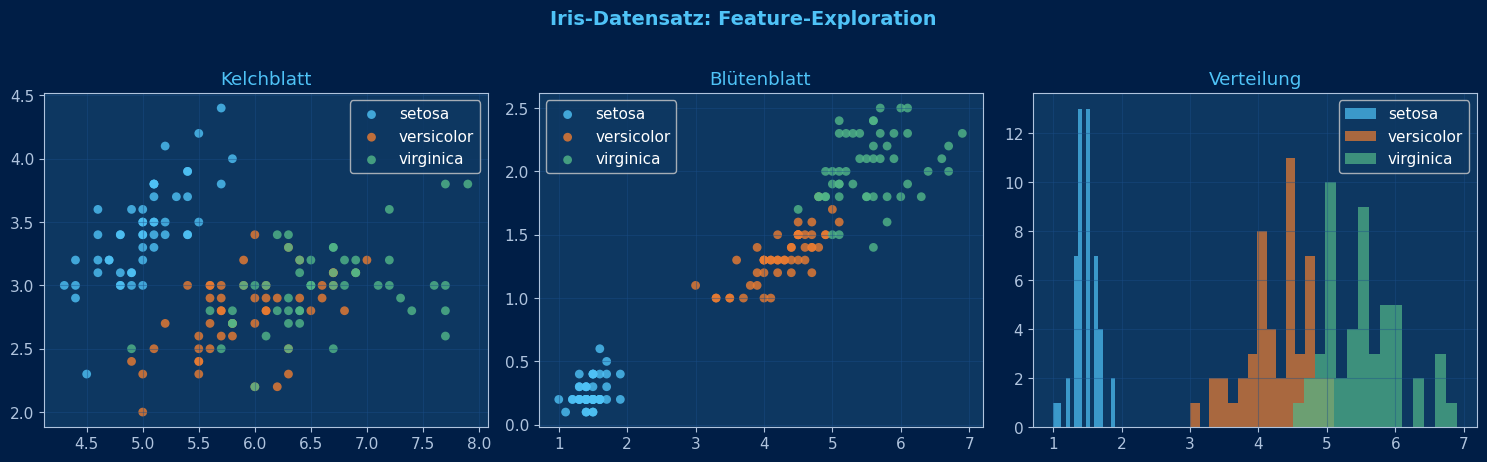


💡 Beobachtung: Setosa (blau) ist klar getrennt.
   Versicolor (orange) und Virginica (grün) überlappen leicht.
   Ein gutes Modell muss genau diese Grenze lernen.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 1.2: Daten visualisieren
# Regel: Schau dir die Daten an, BEVOR du ein Modell trainierst!
# ─────────────────────────────────────────────────────────────────────────────

# Farben für die drei Blumenklassen festlegen
colors3 = [C['ice'], C['orange'], C['green']]

# Drei nebeneinanderliegende Diagramme erstellen
# figsize=(15, 4.5) → Breite 15, Höhe 4.5 (in Zoll)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Iris-Datensatz: Feature-Exploration',
             fontsize=14, color=C['ice'], fontweight='bold', y=1.02)

# ── Streudiagramme und Histogramm ────────────────────────────────────────────
# Wir iterieren über 3 Achsen (ax) und wählen je zwei Features zum Vergleich
for ax, fx, fy, title in zip(axes, [0, 2, 2], [1, 3, 2], ['Kelchblatt', 'Blütenblatt', 'Verteilung']):
    for i, (col, lbl) in enumerate(zip(colors3, names)):
        mask = y == i   # Maske: nur die Punkte der aktuellen Klasse auswählen

        if ax == axes[2]:
            # Histogramm: zeigt Verteilung von petal length pro Klasse
            ax.hist(X[mask, fx], bins=15, alpha=0.7, color=col, label=lbl)
        else:
            # Streudiagramm: Kelch- bzw. Blütenblatt-Länge vs. -Breite
            ax.scatter(X[mask, fx], X[mask, fy],
                       c=col, label=lbl, alpha=0.8, s=40, edgecolors='none')

    ax.set_title(title, color=C['ice'])
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

print()
print('💡 Beobachtung: Setosa (blau) ist klar getrennt.')
print('   Versicolor (orange) und Virginica (grün) überlappen leicht.')
print('   Ein gutes Modell muss genau diese Grenze lernen.')


### 📐 Train-Test-Split: Die goldene Regel des Machine Learnings

Bevor wir ein Modell trainieren, **teilen wir die Daten auf**:

| Anteil | Verwendung |
|--------|------------|
| **80% Training** | Das Modell lernt aus diesen Daten |
| **20% Test** | Damit prüfen wir, ob das Modell auch auf *unbekannte* Daten passt |

> ⚠️ **Goldene Regel:** Das Testset darf das Modell während des Trainings **niemals** sehen.
> Wenn man auf Testdaten trainiert, betrügt man sich selbst — das nennt sich **Data Leakage**.
>
> **Polizei-Analogie:** Das Testset ist wie eine unbekannte Tat. Das Modell (der "Ermittler")
> wurde auf anderen Fällen ausgebildet — und muss jetzt zeigen, ob es den neuen Fall
> korrekt löst. Wer die Lösung schon kennt, lernt nichts.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 1.3: Train-Test-Split
# ─────────────────────────────────────────────────────────────────────────────

# train_test_split() teilt X (Features) und y (Labels) gleichzeitig auf.
# Parameter:
#   test_size=0.2     → 20% der Daten werden zum Testen reserviert
#   random_state=42   → Zufallssaat für Reproduzierbarkeit (immer gleiche Aufteilung)
#   stratify=y        → Stellt sicher, dass alle Klassen proportional vertreten sind
#                       (nicht zufällig alle Setosas ins Testset)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Trainingsdaten:  {X_train.shape[0]} Blumen (80%)')
print(f'Testdaten:       {X_test.shape[0]} Blumen (20%)')
print()
print('Klassenverteilung im Testset:')
for i, name in enumerate(names):
    # sum(y_test == i) zählt, wie viele Einträge den Wert i haben
    print(f'  {name}: {sum(y_test == i)} Blumen')
print()
print('⚠️  Goldene Regel: Das Testset sieht das Modell während Training NIE!')


Trainingsdaten:  120 Blumen (80%)
Testdaten:       30 Blumen (20%)

Klassenverteilung im Testset:
  setosa: 10 Blumen
  versicolor: 10 Blumen
  virginica: 10 Blumen

⚠️  Goldene Regel: Das Testset sieht das Modell während Training NIE!


---
## Teil 2 – Entscheidungsbaum: Das erklärbare Modell

### 🌳 Was ist ein Entscheidungsbaum?

Ein **Entscheidungsbaum** (Decision Tree) ist das intuitivste ML-Modell.
Es stellt Entscheidungslogik als Baum dar — genau wie ein Flussdiagramm:

```
Ist petal length ≤ 2.45 cm?
├── JA  → Klasse: Setosa ✅
└── NEIN → Ist petal width ≤ 1.75 cm?
           ├── JA  → Klasse: Versicolor
           └── NEIN → Klasse: Virginica
```

Das Modell **lernt diese Schwellenwerte automatisch aus den Trainingsdaten**.
Niemand hat dem Algorithmus gesagt "schau auf petal length" — er hat es selbst herausgefunden.

### ✅ Stärken eines Entscheidungsbaums

- **Vollständig erklärbar:** Jede Entscheidung ist nachvollziehbar
- **Visualisierbar:** Der gesamte Baum kann dargestellt werden
- **Kein Preprocessing nötig:** Features müssen nicht skaliert werden
- **Forensisch geeignet:** Vor Gericht muss ein Modell erklärbar sein

### ⚠️ Schwäche

- Tendenz zum **Overfitting** (auswendig lernen) bei zu tiefen Bäumen
- Deshalb: `max_depth=3` begrenzt die Tiefe


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 2.1: Entscheidungsbaum trainieren
# ─────────────────────────────────────────────────────────────────────────────

# DecisionTreeClassifier: Das Modell-Objekt erstellen
# Parameter:
#   max_depth=3      → Maximale Tiefe des Baums (3 Ebenen = gut lesbar & kein Overfitting)
#   random_state=42  → Reproduzierbarkeit bei Gleichständen
tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# .fit() = "Trainieren": Das Modell lernt die Struktur aus X_train und y_train
# Es findet selbst heraus, welche Features und Schwellenwerte am besten trennen
tree.fit(X_train, y_train)

# .predict() = "Vorhersagen": Auf Testdaten anwenden (die das Modell nie gesehen hat)
y_pred_tree = tree.predict(X_test)

# Accuracy: Anteil korrekt klassifizierter Datenpunkte (z.B. 0.967 = 96,7%)
acc_tree = accuracy_score(y_test, y_pred_tree)

print(f'Entscheidungsbaum – Accuracy auf Testdaten: {acc_tree:.2%}')
print()
print('── Baumstruktur als Text ──────────────────────────────────')
# export_text() gibt den Baum als lesbaren Text aus
print(export_text(tree, feature_names=list(feat), max_depth=3))
print()
print('💡 Lesehilfe: "≤ X" bedeutet: Wenn Feature kleiner/gleich X → linker Ast')
print('             "class: setosa" bedeutet: Zugewiesene Klasse am Blattknoten')


Entscheidungsbaum – Accuracy auf Testdaten: 96.67%

── Baumstruktur als Text ──────────────────────────────────
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2


💡 Lesehilfe: "≤ X" bedeutet: Wenn Feature kleiner/gleich X → linker Ast
             "class: setosa" bedeutet: Zugewiesene Klasse am Blattknoten


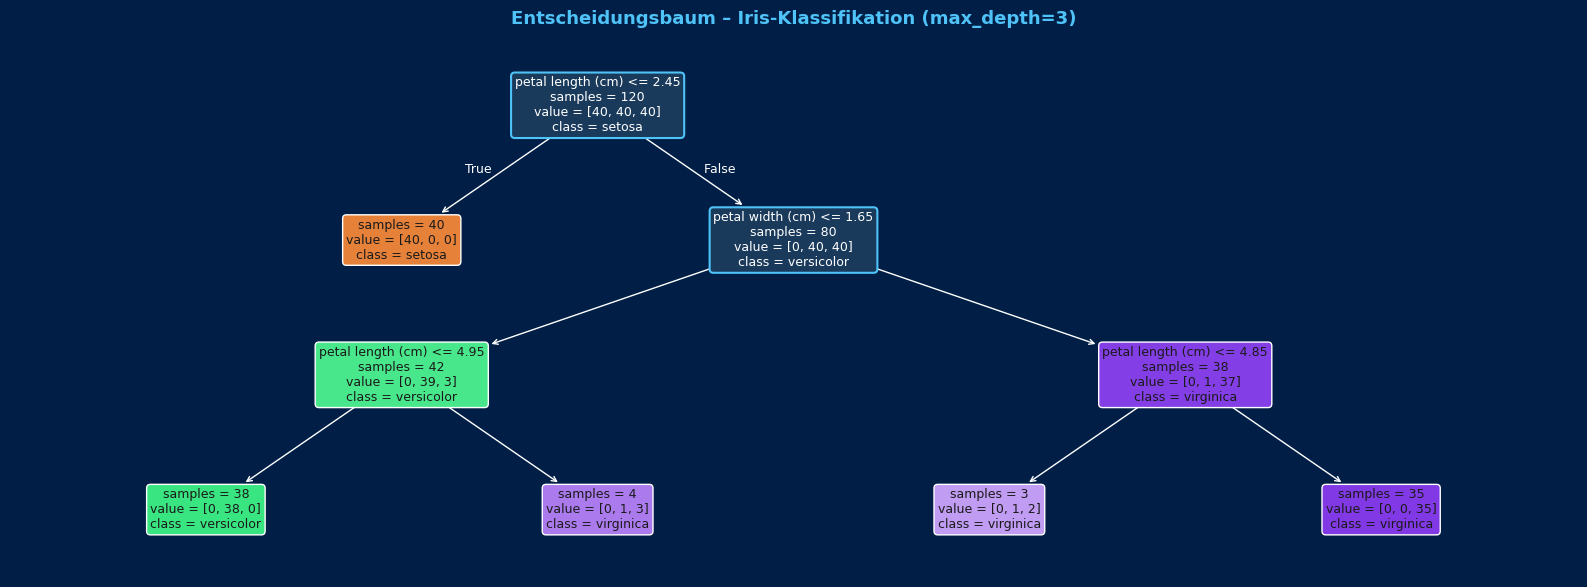


💡 Jeder Pfad vom Wurzelknoten (oben) zum Blattknoten (unten)
   entspricht einer Entscheidungsregel.

🔑 Forensische Relevanz: Dieser Baum könnte vor Gericht
   vollständig erklärt werden: "Das Modell hat so entschieden, weil..."


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 2.2: Entscheidungsbaum visualisieren
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(C['navy'])
ax.set_facecolor(C['navy'])

# plot_tree() zeichnet den Baum grafisch
# filled=True   → Knoten werden nach Klasse eingefärbt
# rounded=True  → Abgerundete Ecken (besser lesbar)
# fontsize=9    → Schriftgröße innerhalb der Knoten
artists = plot_tree(
    tree,
    feature_names=list(feat),
    class_names=list(names),
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False   # Gini-Index ausblenden (für Einsteiger verwirrend)
)

# ── Lesbarkeits-Fix: gemischte Knoten nachfärben ──────────────────────────────
# plot_tree() färbt Knoten mit gemischter Klassenzusammensetzung reinweiß ein.
# Das führt zu weißer Schrift auf weißem Hintergrund → unleserlich.
# Lösung: Alle zu hellen Knoten (Luminanz > 0.75) auf Dunkelblau setzen.
MIXED_COLOR = '#1A3A5C'   # Dunkelblau für "unentschiedene" (gemischte) Knoten
for artist in artists:
    bp = artist.get_bbox_patch()
    if bp is None:
        continue
    r, g, b, _ = bp.get_facecolor()
    # Luminanz berechnen (Standard-Formel für menschliche Helligkeitswahrnehmung)
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    if lum > 0.75:
        # Zu heller Hintergrund: dunkel einfärben, Rahmen hervorheben
        bp.set_facecolor(MIXED_COLOR)
        bp.set_edgecolor(C['ice'])
        bp.set_linewidth(1.5)
        artist.set_color('#FFFFFF')   # Weiße Schrift auf dunklem Grund
    else:
        artist.set_color('#1A1A1A')   # Dunkle Schrift auf hellen Klassen-Knoten

ax.set_title('Entscheidungsbaum – Iris-Klassifikation (max_depth=3)',
             fontsize=13, color=C['ice'], fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

print()
print('💡 Jeder Pfad vom Wurzelknoten (oben) zum Blattknoten (unten)')
print('   entspricht einer Entscheidungsregel.')
print()
print('🔑 Forensische Relevanz: Dieser Baum könnte vor Gericht')
print('   vollständig erklärt werden: "Das Modell hat so entschieden, weil..."')


---
## Teil 3 – MLP: Das neuronale Netz

### 🧠 Was ist ein MLP (Multi-Layer Perceptron)?

Ein **Multi-Layer Perceptron** ist die einfachste Form eines neuronalen Netzes.
Es besteht aus:

| Schicht | Funktion |
|---------|----------|
| **Eingabeschicht** | Nimmt die Features entgegen (hier: 4 Blumenmessungen) |
| **Versteckte Schichten** | Lernen komplexe Muster (hier: 2 Schichten mit 64 und 32 Neuronen) |
| **Ausgabeschicht** | Gibt die Klassenwahrscheinlichkeit aus |

Jedes **Neuron** berechnet eine gewichtete Summe seiner Eingaben und sendet
das Ergebnis weiter — falls ein Schwellenwert überschritten wird (**ReLU-Aktivierung**).

### ⚠️ Wichtig: Feature-Skalierung!

Ein neuronales Netz benötigt **skalierte Features** — alle Werte sollten ähnlich groß sein.
Wenn ein Feature Werte von 0–10 hat und ein anderes 0–10.000, dominiert das große Feature.

**StandardScaler** löst das:
- Berechnet Mittelwert und Standardabweichung aus den **Trainingsdaten**
- Transformiert alle Features auf Mittelwert 0 und Standardabweichung 1
- ⚠️ Wichtig: `fit_transform()` nur auf Trainingsdaten — `transform()` auf Testdaten!


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 3.1: Feature-Skalierung (zwingend erforderlich für MLP)
# ─────────────────────────────────────────────────────────────────────────────

# StandardScaler lernt Mittelwert und Standardabweichung aus X_train
scaler = StandardScaler()

# fit_transform() = Lernen + Anwenden auf Trainingsdaten in einem Schritt
X_tr_sc = scaler.fit_transform(X_train)

# transform() = Nur Anwenden (mit den aus Training gelernten Werten!)
# NIEMALS fit_transform() auf Testdaten – das wäre Data Leakage!
X_te_sc = scaler.transform(X_test)

print('Skalierung abgeschlossen.')
print()
print('Beispiel – Original vs. Skaliert (erste Blume, Feature 0):')
print(f'  Original:  {X_train[0, 0]:.2f} cm')
print(f'  Skaliert:  {X_tr_sc[0, 0]:.4f} (Einheit: Standardabweichungen vom Mittelwert)')


Skalierung abgeschlossen.

Beispiel – Original vs. Skaliert (erste Blume, Feature 0):
  Original:  4.40 cm
  Skaliert:  -1.7216 (Einheit: Standardabweichungen vom Mittelwert)


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 3.2: MLP trainieren
# ─────────────────────────────────────────────────────────────────────────────

# MLPClassifier erstellen
# Parameter:
#   hidden_layer_sizes=(64, 32)  → 2 versteckte Schichten: erste mit 64, zweite mit 32 Neuronen
#   activation='relu'            → Aktivierungsfunktion: ReLU (Rectified Linear Unit)
#                                  Gibt 0 aus wenn Eingabe negativ, sonst die Eingabe selbst
#   max_iter=300                 → Maximale Anzahl Trainingsdurchläufe (Epochen)
#   random_state=42              → Reproduzierbarkeit
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=300,
    random_state=42
)

# .fit() auf den SKALIERTEN Trainingsdaten
mlp.fit(X_tr_sc, y_train)

# Accuracy auf skalierten Testdaten berechnen
acc_mlp = accuracy_score(y_test, mlp.predict(X_te_sc))

print(f'MLP (64→32 Neuronen, ReLU) – Accuracy: {acc_mlp:.2%}')
print(f'Entscheidungsbaum           – Accuracy: {acc_tree:.2%}')
print()
print(f'Anzahl Trainingsepochen: {mlp.n_iter_}')
print(f'Finaler Loss-Wert:       {mlp.loss_:.6f}')


MLP (64→32 Neuronen, ReLU) – Accuracy: 96.67%
Entscheidungsbaum           – Accuracy: 96.67%

Anzahl Trainingsepochen: 300
Finaler Loss-Wert:       0.038592


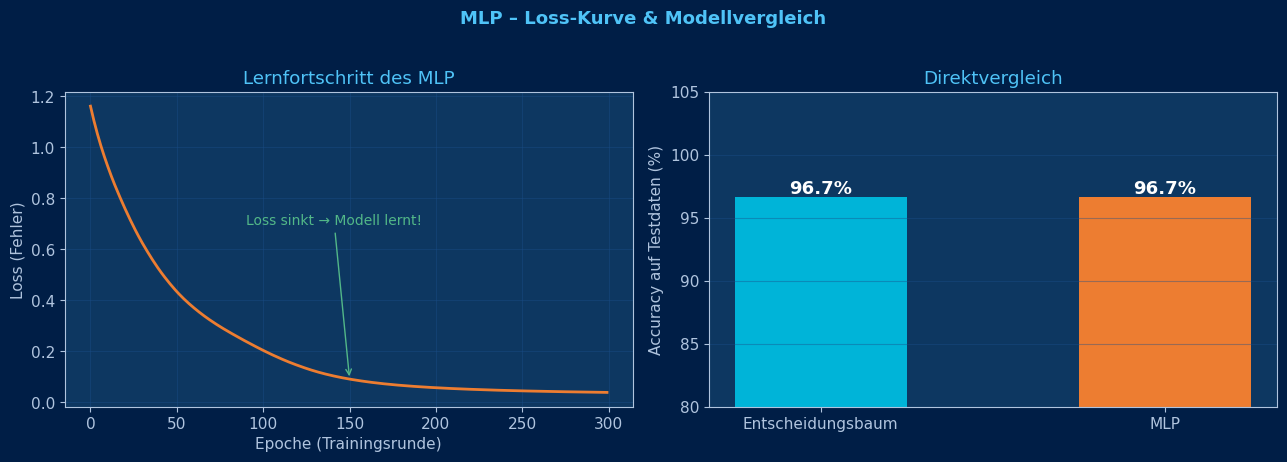


💡 Beobachtung: Bei kleinen, sauberen Datensätzen liegen beide Modelle
   oft gleichauf. Der Entscheidungsbaum hat jedoch den Vorteil:
   Er ist vollständig erklärbar.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 3.3: Loss-Kurve und Modellvergleich visualisieren
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('MLP – Loss-Kurve & Modellvergleich',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)

# ── Linkes Diagramm: Loss-Kurve ───────────────────────────────────────────────
# mlp.loss_curve_ enthält den Fehlerwert nach jeder Trainingsepoche
# Ein sinkender Loss zeigt, dass das Modell lernt
axes[0].plot(mlp.loss_curve_, color=C['orange'], lw=2)
axes[0].set_xlabel('Epoche (Trainingsrunde)')
axes[0].set_ylabel('Loss (Fehler)')
axes[0].set_title('Lernfortschritt des MLP', color=C['ice'])
axes[0].grid(True)
# Annotation für Erklärung
axes[0].annotate('Loss sinkt → Modell lernt!',
                 xy=(mlp.n_iter_ * 0.5, mlp.loss_curve_[mlp.n_iter_ // 2]),
                 xytext=(mlp.n_iter_ * 0.3, mlp.loss_curve_[0] * 0.6),
                 color=C['green'], fontsize=10,
                 arrowprops=dict(arrowstyle='->', color=C['green']))

# ── Rechtes Diagramm: Accuracy-Vergleich ─────────────────────────────────────
bars = axes[1].bar(
    ['Entscheidungsbaum', 'MLP'],
    [acc_tree * 100, acc_mlp * 100],
    color=[C['teal'], C['orange']],
    width=0.5
)
# Prozentangabe auf jedem Balken
for bar, acc in zip(bars, [acc_tree * 100, acc_mlp * 100]):
    axes[1].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3,
                 f'{acc:.1f}%', ha='center', fontweight='bold',
                 color=C['white'], fontsize=13)
axes[1].set_ylim(80, 105)
axes[1].set_ylabel('Accuracy auf Testdaten (%)')
axes[1].set_title('Direktvergleich', color=C['ice'])
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

print()
print('💡 Beobachtung: Bei kleinen, sauberen Datensätzen liegen beide Modelle')
print('   oft gleichauf. Der Entscheidungsbaum hat jedoch den Vorteil:')
print('   Er ist vollständig erklärbar.')


---
## Teil 4 – Konfusionsmatrix & Bewertungsmetriken

### 📊 Warum reicht Accuracy allein nicht?

Stellen Sie sich vor, ein Modell erkennt Angriffe auf ein Netzwerk.
Von 1.000 Verbindungen sind 990 normal und 10 echte Angriffe.

Ein Modell, das **immer "Normal" sagt**, hat eine Accuracy von **99%** — ist aber **wertlos**,
weil es alle Angriffe verpasst!

Deshalb brauchen wir differenziertere Metriken:

| Metrik | Definition | Polizei-Analogie |
|--------|------------|-----------------|
| **Precision** | Von allen als Angriff klassifizierten: Wie viele sind wirklich Angriffe? | Treffsicherheit: Keine falschen Verdächtigen |
| **Recall** | Von allen echten Angriffen: Wie viele wurden erkannt? | Vollständigkeit: Keinen echten Täter verpassen |
| **F1-Score** | Harmonisches Mittel aus Precision und Recall | Balance zwischen beiden |

> 🔑 **Faustregel:** Bei unausgeglichenen Klassen (z.B. 990 normal, 10 Angriff)
> immer **F1-Score** und **Recall** statt nur Accuracy bewerten!

### Die Konfusionsmatrix

```
              Vorhergesagt
              Normal  Angriff
Wahr Normal  [  TN     FP  ]   TN = True Negative  (korrekt: Normal als Normal)
     Angriff [  FN     TP  ]   TP = True Positive  (korrekt: Angriff als Angriff)
                               FP = False Positive (Fehler:  Normal als Angriff)
                               FN = False Negative (Fehler:  Angriff als Normal) ← GEFÄHRLICH
```


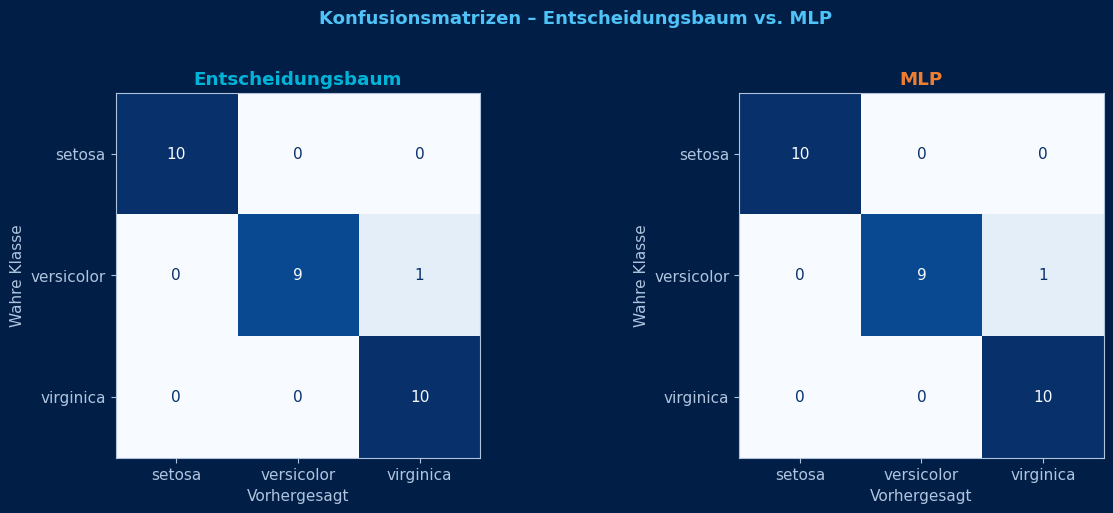


💡 Lesehilfe: Diagonale (oben-links → unten-rechts) = korrekte Vorhersagen
   Werte NEBEN der Diagonale = Fehler (Verwechslungen)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 4.1: Konfusionsmatrizen visualisieren
# ─────────────────────────────────────────────────────────────────────────────

# Vorhersagen beider Modelle auf Testdaten
y_pred_tree = tree.predict(X_test)
y_pred_mlp  = mlp.predict(X_te_sc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Konfusionsmatrizen – Entscheidungsbaum vs. MLP',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)

for ax, pred, title, col in zip(
    axes,
    [y_pred_tree, y_pred_mlp],
    ['Entscheidungsbaum', 'MLP'],
    [C['teal'], C['orange']]
):
    # confusion_matrix() berechnet die 3×3-Matrix (3 Klassen)
    cm = confusion_matrix(y_test, pred)

    # ConfusionMatrixDisplay visualisiert die Matrix
    ConfusionMatrixDisplay(cm, display_labels=names).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(title, color=col, fontweight='bold')
    ax.set_xlabel('Vorhergesagt')
    ax.set_ylabel('Wahre Klasse')

plt.tight_layout()
plt.show()

print()
print('💡 Lesehilfe: Diagonale (oben-links → unten-rechts) = korrekte Vorhersagen')
print('   Werte NEBEN der Diagonale = Fehler (Verwechslungen)')


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 4.2: Detaillierter Bewertungsbericht
# ─────────────────────────────────────────────────────────────────────────────

print('━' * 55)
print('ENTSCHEIDUNGSBAUM – Detaillierter Bericht:')
print('━' * 55)
# classification_report() gibt Precision, Recall, F1 für jede Klasse aus
print(classification_report(y_test, y_pred_tree, target_names=names))

print('━' * 55)
print('MLP – Detaillierter Bericht:')
print('━' * 55)
print(classification_report(y_test, y_pred_mlp, target_names=names))

print()
print('Erläuterung der Spalten:')
print('  precision  = Von allen als Klasse X vorhergesagten: Anteil korrekt')
print('  recall     = Von allen echten Klasse-X: Anteil erkannt')
print('  f1-score   = Harmonisches Mittel aus precision & recall')
print('  support    = Anzahl echter Beispiele dieser Klasse im Testset')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ENTSCHEIDUNGSBAUM – Detaillierter Bericht:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MLP – Detaillierter Bericht:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        

---
## Teil 5 – 🚔 NSL-KDD: Echte Netzwerk-Forensik

### Was ist NSL-KDD?

**NSL-KDD** ist der Standard-Benchmark-Datensatz für **Network Intrusion Detection** —
die automatische Erkennung von Netzwerkangriffen.

Er basiert auf dem **DARPA-Datensatz** (US-Verteidigungsministerium) und enthält
echte Netzwerkverbindungen aus einer kontrollierten Testumgebung.

| Merkmal | Details |
|---------|---------|
| Original-Quelle | Canadian Institute for Cybersecurity (UNB), 2009 |
| Anwendung | Eingesetzt in Tausenden ML-Forschungsarbeiten weltweit |
| Verbindungstypen | Normale Verbindungen + 4 Angriffsklassen |
| Standard | Gold-Standard für IDS (Intrusion Detection Systems) |

### 🎯 Angriffsklassen in unserem Datensatz

| Angriffstyp | Kategorie | Beschreibung |
|-------------|-----------|--------------|
| `normal` | – | Regulärer Netzwerkverkehr |
| `neptune` | **DoS** (Denial of Service) | SYN-Flood: Überflutet Server mit halboffenen TCP-Verbindungen |
| `portsweep` | **Probe** (Aufklärung) | Portscanner: Systematisches Abtasten aller offenen Ports |
| `guess_passwd` | **R2L** (Remote to Local) | Passwort-Brute-Force: Tausende Anmeldeversuche |

### 🔑 Unsere Features (8 ausgewählte Merkmale)

| Feature | Bedeutung | Forensische Relevanz |
|---------|-----------|----------------------|
| `duration` | Verbindungsdauer in Sekunden | SYN-Floods dauern 0 Sekunden |
| `src_bytes` | Gesendete Bytes (Client → Server) | Bei DoS: nur kleine SYN-Pakete |
| `dst_bytes` | Empfangene Bytes (Server → Client) | Bei DoS: 0 (Server antwortet nicht) |
| `logged_in` | Erfolgreich eingeloggt? (0/1) | Angreifer sind oft nicht eingeloggt |
| `num_failed_logins` | Anzahl fehlgeschlagener Logins | Brute-Force: sehr hoher Wert |
| `serror_rate` | Rate SYN-Error-Verbindungen (0–1) | Neptune: nahe 1.0 |
| `rerror_rate` | Rate REJ-Error-Verbindungen (0–1) | Portsweep: hoch (viele geschlossene Ports) |
| `dst_host_count` | Anzahl verschiedener Ziel-Hosts | Portsweep: sehr hoch (viele Ziele) |

> 📌 **Datenbezug:** Wir laden den **echten NSL-KDD-Datensatz** (20%-Subset, ~25.000 Verbindungen)
> direkt von GitHub: [mb4n6/AI_Advanced](https://github.com/mb4n6/AI_Advanced)
> Das Notebook benötigt eine Internetverbindung — in Google Colab ist das immer gegeben.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.1: NSL-KDD Datensatz laden
#
# Quelle: https://github.com/mb4n6/AI_Advanced/blob/main/KDDTrain%2B_20Percent.txt
# Originaldatensatz: Canadian Institute for Cybersecurity (UNB), 2009
#
# Der Datensatz liegt auf GitHub und wird direkt von dort geladen.
# Vorteil: Echter Datensatz (~25.000 Verbindungen), kein lokaler Download nötig.
# ─────────────────────────────────────────────────────────────────────────────

# ── Spaltennamen definieren ───────────────────────────────────────────────────
# NSL-KDD hat 41 Features + 1 Label + 1 Schwierigkeitswert (difficulty).
# Die Originaldatei hat KEINEN Header – wir vergeben die Namen selbst.
# (Offizielle Spaltennamen aus der NSL-KDD Dokumentation)
NSL_KDD_COLS = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label',       # Verbindungstyp: 'normal', 'neptune', 'portsweep', etc.
    'difficulty'   # Schwierigkeitswert (1–21) – für uns irrelevant, wird verworfen
]

# ── Datei von GitHub laden ────────────────────────────────────────────────────
# Die Raw-URL zeigt direkt auf die Textdatei (kein HTML, reines CSV)
RAW_URL = (
    'https://raw.githubusercontent.com/mb4n6/AI_Advanced/main/'
    'KDDTrain%2B_20Percent.txt'
)

print('⏳ Lade NSL-KDD Datensatz von GitHub...')
print(f'   URL: {RAW_URL}')
print()

# pd.read_csv() kann URLs direkt lesen – kein manueller Download nötig
# header=None  → Datei hat keine Kopfzeile
# names=...    → Wir vergeben die Spaltennamen manuell
df_kdd_raw = pd.read_csv(RAW_URL, header=None, names=NSL_KDD_COLS)

# ── Spalte 'difficulty' entfernen (für uns nicht relevant) ───────────────────
# 'difficulty' entfernen falls vorhanden (Originaldatei hat diese Spalte)
df_kdd_raw = df_kdd_raw.drop(columns=['difficulty'], errors='ignore')

print(f'✅  Datensatz geladen: {len(df_kdd_raw):,} Verbindungen × {df_kdd_raw.shape[1]} Spalten')
print()

# ── Überblick: Welche Angriffsklassen sind enthalten? ────────────────────────
print('Alle Verbindungstypen im Datensatz:')
label_counts = df_kdd_raw['label'].value_counts()
for label, count in label_counts.items():
    anteil = count / len(df_kdd_raw) * 100
    # Angriffe farblich markieren (in Textform)
    marker = '  ← Angriff' if label != 'normal' else ''
    print(f'  {label:20s}: {count:6,} ({anteil:5.1f}%){marker}')


⏳ Lade NSL-KDD Datensatz von GitHub...
   URL: https://raw.githubusercontent.com/mb4n6/AI_Advanced/main/KDDTrain%2B_20Percent.txt

✅  Datensatz geladen: 25,192 Verbindungen × 42 Spalten

Alle Verbindungstypen im Datensatz:
  normal              : 13,449 ( 53.4%)
  neptune             :  8,282 ( 32.9%)  ← Angriff
  ipsweep             :    710 (  2.8%)  ← Angriff
  satan               :    691 (  2.7%)  ← Angriff
  portsweep           :    587 (  2.3%)  ← Angriff
  smurf               :    529 (  2.1%)  ← Angriff
  nmap                :    301 (  1.2%)  ← Angriff
  back                :    196 (  0.8%)  ← Angriff
  teardrop            :    188 (  0.7%)  ← Angriff
  warezclient         :    181 (  0.7%)  ← Angriff
  pod                 :     38 (  0.2%)  ← Angriff
  guess_passwd        :     10 (  0.0%)  ← Angriff
  warezmaster         :      7 (  0.0%)  ← Angriff
  buffer_overflow     :      6 (  0.0%)  ← Angriff
  imap                :      5 (  0.0%)  ← Angriff
  rootkit             :

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.1b: Für das Seminar relevante Klassen filtern
#
# Der vollständige Datensatz enthält ~23 Angriffsklassen.
# Wir konzentrieren uns auf 4 repräsentative Klassen, die alle großen
# Angriffskategorien abdecken:
#
#   normal       → normaler Netzwerkverkehr (Referenzklasse)
#   neptune      → DoS  (Denial of Service): SYN-Flood
#   portsweep    → Probe (Aufklärung):        Portscanner
#   guess_passwd → R2L  (Remote to Local):    Passwort-Brute-Force
#
# Diese vier Klassen sind lehrreich, gut unterscheidbar und forensisch relevant.
# ─────────────────────────────────────────────────────────────────────────────

AUSWAHL = ['normal', 'neptune', 'portsweep', 'guess_passwd']

# .isin() filtert: behalte nur Zeilen, deren Label in der Auswahlliste steht
df_kdd = df_kdd_raw[df_kdd_raw['label'].isin(AUSWAHL)].copy()

# Für Reproduzierbarkeit: gleiche Stichprobengröße bei jeder Ausführung
# Wir nehmen maximal 2.000 Zeilen pro Klasse (verhindert Klassenungleichgewicht
# durch die sehr große 'normal'-Klasse)
MAX_PRO_KLASSE = 2000

# pd.concat() mit list comprehension: für jede Klasse separat sampeln, dann zusammenführen
# Diese Methode ist robuster als groupby().apply() über verschiedene pandas-Versionen
df_kdd = pd.concat([
    grp.sample(min(len(grp), MAX_PRO_KLASSE), random_state=42)
    for _, grp in df_kdd.groupby('label')
]).sample(frac=1, random_state=42).reset_index(drop=True)
# .sample(frac=1) = alles sampeln = mischen; random_state für Reproduzierbarkeit

print('Gefilterter Datensatz (4 Klassen, max. 2.000 je Klasse):')
for label, count in df_kdd['label'].value_counts().items():
    anteil = count / len(df_kdd) * 100
    print(f'  {label:20s}: {count:5,} ({anteil:.1f}%)')
print(f'\nGesamt: {len(df_kdd):,} Verbindungen')
print()
print('Erste 3 Einträge:')
df_kdd[['duration','src_bytes','dst_bytes','logged_in',
        'num_failed_logins','serror_rate','rerror_rate',
        'dst_host_count','label']].head(3)


Gefilterter Datensatz (4 Klassen, max. 2.000 je Klasse):
  neptune             : 2,000 (43.5%)
  normal              : 2,000 (43.5%)
  portsweep           :   587 (12.8%)
  guess_passwd        :    10 (0.2%)

Gesamt: 4,597 Verbindungen

Erste 3 Einträge:


,duration,src_bytes,dst_bytes,logged_in,num_failed_logins,serror_rate,rerror_rate,dst_host_count,label
0,0,0,0,0,0,1.0,0.0,255,neptune
1,0,195,377,1,0,0.0,0.0,11,normal
2,0,0,0,0,0,1.0,0.0,255,neptune


### 🔍 Visualisierung: Wie unterscheiden sich Angriffe von normalem Verkehr?

Bevor wir das Modell trainieren, schauen wir uns die Daten an.
Können wir mit bloßem Auge Angriffsmuster erkennen?


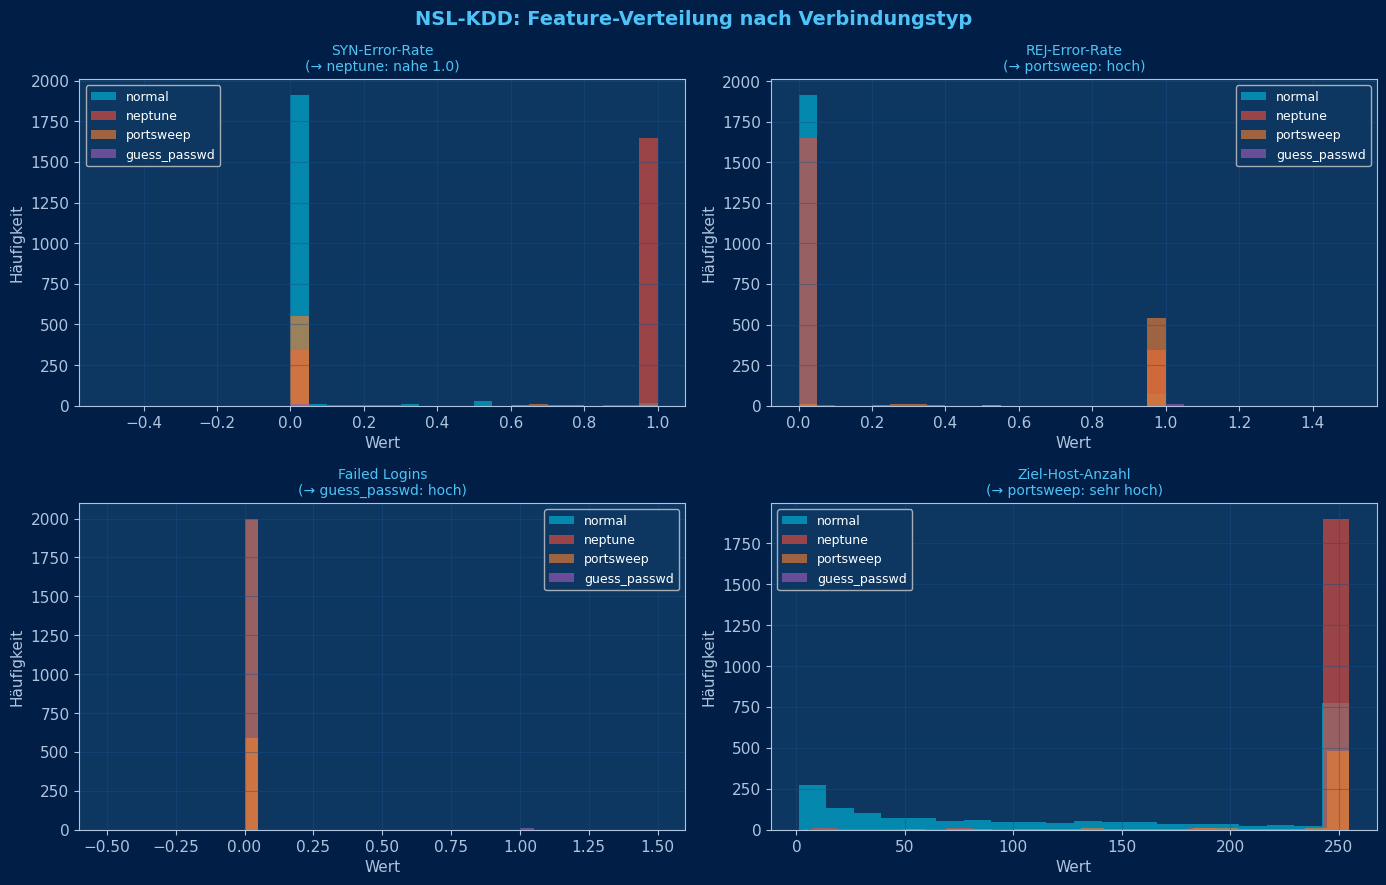


💡 Beobachtungen:
  1. serror_rate: neptune (rot) konzentriert sich bei ~1.0 – klares Signal!
  2. rerror_rate: portsweep (orange) hat hohe Werte – viele abgelehnte Ports
  3. num_failed_logins: guess_passwd (lila) hat hohe Werte – Brute Force sichtbar
  4. dst_host_count: portsweep hat viele Ziel-Hosts – breiter Scan


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.2: Feature-Verteilung visualisieren
# Ziel: Sind die Angriffe in den Features erkennbar?
# ─────────────────────────────────────────────────────────────────────────────

# Vier Features mit hoher Trennkraft visualisieren
plot_features = ['serror_rate', 'rerror_rate', 'num_failed_logins', 'dst_host_count']
feature_labels = [
    'SYN-Error-Rate\n(→ neptune: nahe 1.0)',
    'REJ-Error-Rate\n(→ portsweep: hoch)',
    'Failed Logins\n(→ guess_passwd: hoch)',
    'Ziel-Host-Anzahl\n(→ portsweep: sehr hoch)'
]

# Farb-Dictionary für die vier Klassen
klassen_farben = {
    'normal':       C['teal'],
    'neptune':      C['red'],
    'portsweep':    C['orange'],
    'guess_passwd': C['purple']
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('NSL-KDD: Feature-Verteilung nach Verbindungstyp',
             fontsize=14, color=C['ice'], fontweight='bold')

# Alle Subplots als flache Liste
axes_flat = axes.flatten()

for ax, feat, feat_label in zip(axes_flat, plot_features, feature_labels):
    # Für jede Klasse ein eigenes Histogramm überlagern
    for klasse, farbe in klassen_farben.items():
        # Nur die Zeilen der aktuellen Klasse auswählen
        werte = df_kdd.loc[df_kdd['label'] == klasse, feat]
        ax.hist(werte, bins=20, alpha=0.65, color=farbe, label=klasse)

    ax.set_title(feat_label, color=C['ice'], fontsize=10)
    ax.set_xlabel('Wert')
    ax.set_ylabel('Häufigkeit')
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.show()

print()
print('💡 Beobachtungen:')
print('  1. serror_rate: neptune (rot) konzentriert sich bei ~1.0 – klares Signal!')
print('  2. rerror_rate: portsweep (orange) hat hohe Werte – viele abgelehnte Ports')
print('  3. num_failed_logins: guess_passwd (lila) hat hohe Werte – Brute Force sichtbar')
print('  4. dst_host_count: portsweep hat viele Ziel-Hosts – breiter Scan')


### 🏷️ Labels für das Modell aufbereiten

Unser aktuelles Label ist ein **Text** (`'normal'`, `'neptune'`, ...).
Die meisten ML-Algorithmen erwarten **Zahlen**.

Wir haben zwei Optionen:

1. **Binäre Klassifikation:** normal = 0, alles andere = 1 (Angriff ja/nein)
2. **Multi-Klassen-Klassifikation:** normal=0, neptune=1, portsweep=2, guess_passwd=3

Wir verwenden hier **Option 2** — das Modell soll die Angriffsart bestimmen,
nicht nur ob ein Angriff vorliegt.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.3: Features und Labels extrahieren, Labels kodieren
# ─────────────────────────────────────────────────────────────────────────────

# Liste der 8 Features, die wir verwenden
FEATURES = ['duration', 'src_bytes', 'dst_bytes', 'logged_in',
            'num_failed_logins', 'serror_rate', 'rerror_rate', 'dst_host_count']

# X_kdd = Feature-Matrix (alle Verbindungen, nur die 8 Spalten)
# .values wandelt den DataFrame in ein NumPy-Array um (für sklearn nötig)
X_kdd = df_kdd[FEATURES].values

# Labels: Text in Zahlen umwandeln
# LabelEncoder() weist automatisch Zahlen zu: alphabetisch → guess_passwd=0, neptune=1, ...
le = LabelEncoder()
y_kdd = le.fit_transform(df_kdd['label'])

# Welche Zahl entspricht welcher Klasse?
print('Label-Kodierung (LabelEncoder):')
for zahl, name in enumerate(le.classes_):
    anzahl = sum(df_kdd['label'] == name)
    print(f'  {zahl} → {name:15s} ({anzahl} Verbindungen)')

print()
print(f'Feature-Matrix X: {X_kdd.shape[0]} Verbindungen × {X_kdd.shape[1]} Features')
print(f'Label-Vektor y:   {len(y_kdd)} Werte (Zahlen 0–{len(le.classes_)-1})')


Label-Kodierung (LabelEncoder):
  0 → guess_passwd    (10 Verbindungen)
  1 → neptune         (2000 Verbindungen)
  2 → normal          (2000 Verbindungen)
  3 → portsweep       (587 Verbindungen)

Feature-Matrix X: 4597 Verbindungen × 8 Features
Label-Vektor y:   4597 Werte (Zahlen 0–3)


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.4: Train-Test-Split und Skalierung
# ─────────────────────────────────────────────────────────────────────────────

# 80/20-Split mit stratify – wichtig bei ungleicher Klassenverteilung
X_kdd_train, X_kdd_test, y_kdd_train, y_kdd_test = train_test_split(
    X_kdd, y_kdd,
    test_size=0.2,
    random_state=42,
    stratify=y_kdd   # Stellt proportionale Klassenverteilung in Train/Test sicher
)

print(f'Trainingsdaten:  {len(X_kdd_train)} Verbindungen')
print(f'Testdaten:       {len(X_kdd_test)} Verbindungen')
print()

# Skalierung für das MLP (Entscheidungsbaum braucht das nicht)
sc_kdd = StandardScaler()
X_kdd_tr_sc = sc_kdd.fit_transform(X_kdd_train)  # Auf Training anpassen + transformieren
X_kdd_te_sc = sc_kdd.transform(X_kdd_test)        # Nur transformieren (NICHT fitten!)

print('Klassenverteilung im Trainingsset:')
for i, name in enumerate(le.classes_):
    count = sum(y_kdd_train == i)
    print(f'  {name:15s}: {count} Verbindungen')


Trainingsdaten:  3677 Verbindungen
Testdaten:       920 Verbindungen

Klassenverteilung im Trainingsset:
  guess_passwd   : 8 Verbindungen
  neptune        : 1600 Verbindungen
  normal         : 1600 Verbindungen
  portsweep      : 469 Verbindungen


### 🤖 Beide Modelle trainieren und vergleichen

Jetzt trainieren wir Entscheidungsbaum und MLP auf den echten NSL-KDD-Daten
und vergleichen ihre Leistung — genau wie wir es mit Iris gemacht haben.

**Wichtige Frage:** Welches Modell eignet sich besser für die Erkennung von Netzwerkangriffen?
- Der Entscheidungsbaum ist erklärbar (forensisch relevant)
- Das MLP ist potenziell genauer


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.5: Entscheidungsbaum auf NSL-KDD trainieren
# ─────────────────────────────────────────────────────────────────────────────

# Hier erlauben wir max_depth=5 (etwas tiefer als bei Iris, da komplexere Daten)
tree_kdd = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_kdd.fit(X_kdd_train, y_kdd_train)

y_pred_tree_kdd = tree_kdd.predict(X_kdd_test)
acc_tree_kdd    = accuracy_score(y_kdd_test, y_pred_tree_kdd)

print(f'Entscheidungsbaum (NSL-KDD) – Accuracy: {acc_tree_kdd:.2%}')
print()

# ── Feature-Importance: Was hat das Modell als wichtig erkannt? ──────────────
print('Die 8 Features nach Wichtigkeit für den Baum:')
importance_pairs = sorted(
    zip(FEATURES, tree_kdd.feature_importances_),
    key=lambda x: x[1], reverse=True
)
for feat_name, imp in importance_pairs:
    # Balken aus Zeichen visualisieren
    bar = '█' * int(imp * 40)
    print(f'  {feat_name:22s} {imp:.4f}  {bar}')

print()
print('💡 Welche Features sind am wichtigsten?')
print('   → Das zeigt uns, welche Netzwerkeigenschaften Angriffe verraten.')


Entscheidungsbaum (NSL-KDD) – Accuracy: 94.57%

Die 8 Features nach Wichtigkeit für den Baum:
  src_bytes              0.6935  ███████████████████████████
  serror_rate            0.1913  ███████
  duration               0.0542  ██
  dst_host_count         0.0509  ██
  num_failed_logins      0.0081  
  dst_bytes              0.0019  
  logged_in              0.0000  
  rerror_rate            0.0000  

💡 Welche Features sind am wichtigsten?
   → Das zeigt uns, welche Netzwerkeigenschaften Angriffe verraten.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.6: MLP auf NSL-KDD trainieren
# ─────────────────────────────────────────────────────────────────────────────

mlp_kdd = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,    # Mehr Epochen für komplexere Daten
    random_state=42
)
mlp_kdd.fit(X_kdd_tr_sc, y_kdd_train)

y_pred_mlp_kdd = mlp_kdd.predict(X_kdd_te_sc)
acc_mlp_kdd    = accuracy_score(y_kdd_test, y_pred_mlp_kdd)

print(f'MLP (NSL-KDD)               – Accuracy: {acc_mlp_kdd:.2%}')
print(f'Entscheidungsbaum (NSL-KDD) – Accuracy: {acc_tree_kdd:.2%}')


MLP (NSL-KDD)               – Accuracy: 94.35%
Entscheidungsbaum (NSL-KDD) – Accuracy: 94.57%


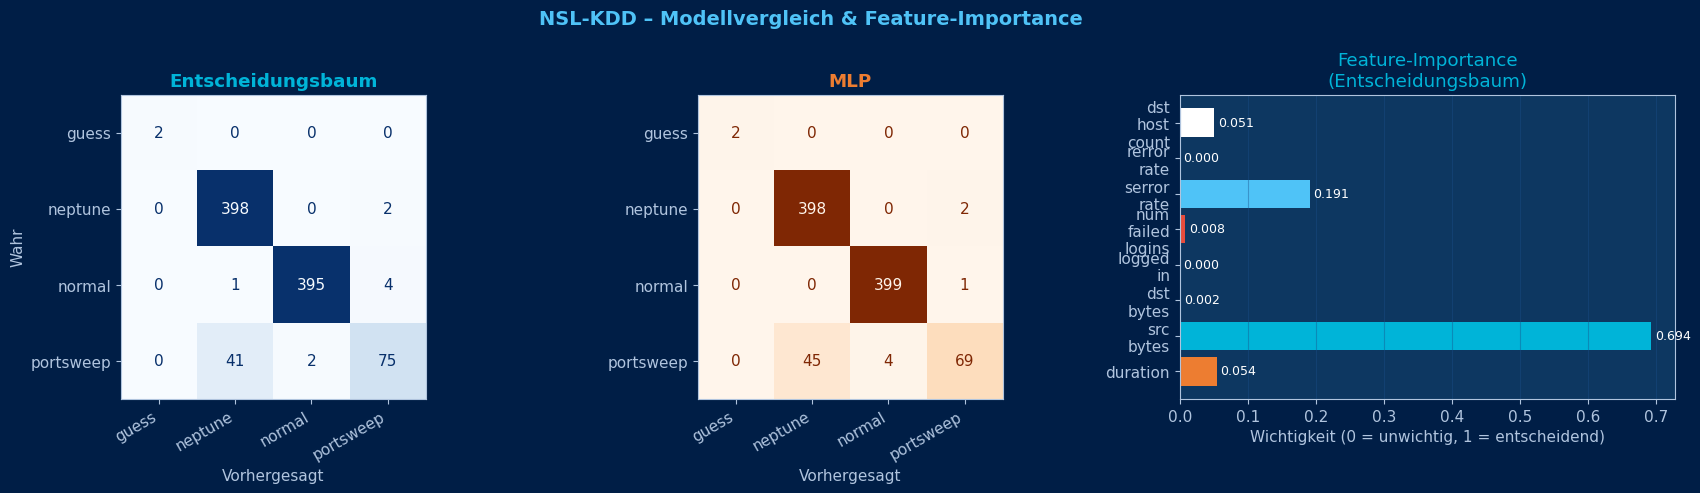

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.7: Konfusionsmatrizen und Feature-Importance visualisieren
# ─────────────────────────────────────────────────────────────────────────────

klassen_namen = list(le.classes_)  # ['guess_passwd', 'neptune', 'normal', 'portsweep']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('NSL-KDD – Modellvergleich & Feature-Importance',
             fontsize=14, color=C['ice'], fontweight='bold')

# ── Konfusionsmatrix Entscheidungsbaum ────────────────────────────────────────
cm_tree = confusion_matrix(y_kdd_test, y_pred_tree_kdd)
ConfusionMatrixDisplay(cm_tree, display_labels=klassen_namen).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Entscheidungsbaum', color=C['teal'], fontweight='bold')
axes[0].set_xlabel('Vorhergesagt'); axes[0].set_ylabel('Wahr')
# Klassenbezeichnungen kürzen für bessere Lesbarkeit
axes[0].set_xticklabels(['guess', 'neptune', 'normal', 'portsweep'], rotation=30, ha='right')
axes[0].set_yticklabels(['guess', 'neptune', 'normal', 'portsweep'])

# ── Konfusionsmatrix MLP ──────────────────────────────────────────────────────
cm_mlp = confusion_matrix(y_kdd_test, y_pred_mlp_kdd)
ConfusionMatrixDisplay(cm_mlp, display_labels=klassen_namen).plot(
    ax=axes[1], colorbar=False, cmap='Oranges'
)
axes[1].set_title('MLP', color=C['orange'], fontweight='bold')
axes[1].set_xlabel('Vorhergesagt'); axes[1].set_ylabel('')
axes[1].set_xticklabels(['guess', 'neptune', 'normal', 'portsweep'], rotation=30, ha='right')
axes[1].set_yticklabels(['guess', 'neptune', 'normal', 'portsweep'])

# ── Feature-Importance (Entscheidungsbaum) ────────────────────────────────────
feat_colors = [C['orange'], C['teal'], C['green'], C['purple'],
               C['red'], C['ice'], C['lgray'], C['white']]
bars = axes[2].barh(
    [f.replace('_', '\n') for f in FEATURES],
    tree_kdd.feature_importances_,
    color=feat_colors
)
axes[2].set_title('Feature-Importance\n(Entscheidungsbaum)', color=C['teal'])
axes[2].set_xlabel('Wichtigkeit (0 = unwichtig, 1 = entscheidend)')
axes[2].grid(True, axis='x')
# Wert am Balken anzeigen
for bar, imp in zip(bars, tree_kdd.feature_importances_):
    axes[2].text(imp + 0.005, bar.get_y() + bar.get_height()/2.,
                 f'{imp:.3f}', va='center', color=C['white'], fontsize=9)

plt.tight_layout()
plt.show()


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.8: Detaillierter Bewertungsbericht für beide Modelle
# ─────────────────────────────────────────────────────────────────────────────

print('━' * 60)
print('ENTSCHEIDUNGSBAUM – Bewertung pro Angriffsklasse:')
print('━' * 60)
print(classification_report(y_kdd_test, y_pred_tree_kdd, target_names=klassen_namen))

print('━' * 60)
print('MLP – Bewertung pro Angriffsklasse:')
print('━' * 60)
print(classification_report(y_kdd_test, y_pred_mlp_kdd, target_names=klassen_namen))

print()
print('🔍 Analyse-Leitfragen für die Diskussion:')
print()
print('  1. Welche Angriffsklasse wird am besten erkannt? Warum?')
print('     (Hinweis: Schauen Sie auf serror_rate für neptune)')
print()
print('  2. Wo verwechseln die Modelle? (Blicke auf die Konfusionsmatrix)')
print()
print('  3. Bei guess_passwd: Ist Recall oder Precision wichtiger?')
print('     (Recall = keinen Angriff verpassen vs. Precision = keine Fehlalarme)')
print()
print('  4. Welches Modell würden Sie in der Praxis einsetzen? Begründen Sie.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ENTSCHEIDUNGSBAUM – Bewertung pro Angriffsklasse:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

guess_passwd       1.00      1.00      1.00         2
     neptune       0.90      0.99      0.95       400
      normal       0.99      0.99      0.99       400
   portsweep       0.93      0.64      0.75       118

    accuracy                           0.95       920
   macro avg       0.96      0.90      0.92       920
weighted avg       0.95      0.95      0.94       920

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MLP – Bewertung pro Angriffsklasse:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

guess_passwd       1.00      1.00      1.00         2
     neptune       0.90      0.99      0.94       400
      normal       0.99      1.00      0.99       400
   portsweep      

### 🎓 Reflexion: Was haben wir gelernt?

#### Feature-Importance: Das Modell erklärt sich selbst

Der Entscheidungsbaum gibt uns **Feature-Importance**-Werte — er zeigt uns,
welche Features er am meisten genutzt hat. Das ist der Schlüssel zur Erklärbarkeit:

- **Hohe `serror_rate`** → wahrscheinlich ein neptune-Angriff (SYN-Flood)
- **Hohe `rerror_rate`** + **hoher `dst_host_count`** → wahrscheinlich portsweep
- **Hohe `num_failed_logins`** + **`logged_in = 0`** → wahrscheinlich guess_passwd

Diese Regeln könnte ein Analyst direkt in ein **SIEM-System** (Security Information
and Event Management) übernehmen — manuell, ohne ML.

#### Wann ist ML sinnvoll?

ML lohnt sich, wenn:
- Die Datenmengen zu groß für manuelle Regeln sind (Millionen Verbindungen/Minute)
- Die Angriffsmuster sich ständig ändern (das Modell kann nachtrainiert werden)
- Komplexe Kombinationen mehrerer Features ein Muster ergeben

> 💡 **Merksatz:** Machine Learning ersetzt nicht das Fachwissen des Analysten —
> es **skaliert** es. Die Feature-Importance zeigt, was das Modell gelernt hat.
> Der Analyst entscheidet, ob das Gelernte sinnvoll ist.


---
## 📋 Zusammenfassung

| Konzept | Was wir gelernt haben | Wo angewendet |
|---------|----------------------|---------------|
| **Features & Labels** | Features = Eingabe, Labels = gewünschte Ausgabe | Iris: Blumenmessungen → Art; KDD: Netzwerkdaten → Angriffstyp |
| **Train/Test-Split** | 80% trainieren, 20% testen — Testdaten NIEMALS zeigen | Beide Datensätze |
| **Entscheidungsbaum** | Erklärbar, visualisierbar, forensisch einsetzbar | Iris + NSL-KDD |
| **MLP** | Feature-Skalierung nötig, Loss-Kurve zeigt Lernfortschritt | Iris + NSL-KDD |
| **Accuracy** | Anteil korrekt klassifizierter Daten | Basismetrik |
| **Precision / Recall** | Präzision vs. Vollständigkeit – bei unbalancierten Klassen entscheidend | NSL-KDD Angriffserkennung |
| **F1-Score** | Balance aus Precision & Recall | NSL-KDD Bewertung |
| **Feature-Importance** | Erklärt, welche Merkmale das Modell nutzt — Grundlage für Erklärbarkeit | NSL-KDD Baum |
| **Konfusionsmatrix** | Zeigt genau, welche Klassen verwechselt werden | Beide Modelle |

---

### 🏁 Nächste Schritte

| Notebook | Inhalt |
|----------|--------|
| **NB-02** (S1.3) | Neuronale Netze von Grund auf – wie lernt ein MLP wirklich? |
| **NB-03** (S1.4) | Ensemble-Methoden: Random Forest & XGBoost |
| **NB-07** (S2.4) | RAG & Vektordatenbanken: Unsupervised Learning in der Praxis |

---

> **KI Advanced · IA1017000 · Hochschule für Polizei Baden-Württemberg**
